In [1]:
import ee 
from RadGEEToolbox import GenericCollection, LandsatCollection, get_palette
# import GEE_UBM
from GEE_UBM import InputCollections, build_model_ready_collection, OriginalUBMRun, ModifiedUBM1Run, check_merged_collection
import geemap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, confusion_matrix, classification_report, accuracy_score

In [2]:
service_account = 'localpythonscripts@ut-gee-ugs-bsf-dev.iam.gserviceaccount.com'
credentials = ee.ServiceAccountCredentials(service_account, 'C:\\Users\\mradwin\\ut-gee-ugs-bsf-dev-53dcc5d729e0.json')
ee.Initialize(credentials=credentials)

# try:
#     ee.Initialize()
# except Exception as e:
#     ee.Authenticate()
#     ee.Initialize()

#### Section 1 - Initial definition of images to use for predicting soil thickness - THIS WHOLE SECTION IS UNNECCESARY TO RUN AS ALL THESE RASTERS ARE NOW COMBINED INTO A SINGLE GEE ASSET - KEEPING THIS HERE AS A REFERENCE

In [3]:
UT_boundary = ee.FeatureCollection("projects/ut-gee-ugs-bsf-dev/assets/Utah_Regional_Boundary").geometry()

In [ ]:

gNATSGO_col = ee.ImageCollection('projects/sat-io/open-datasets/gNATSGO/raster/tk0_999a')
native_projection = gNATSGO_col.first().select(0).projection()
gNATSGO = gNATSGO_col.mosaic().multiply(10).clip(UT_boundary).setDefaultProjection(native_projection).rename('tk0_999a') #.reproject(native_projection)
print(gNATSGO_col.first().projection().nominalScale().getInfo())
print(gNATSGO.projection().nominalScale().getInfo())

10
10


In [6]:
landsat_col = LandsatCollection(start_date='2015-01-01', end_date='2025-12-31', boundary=UT_boundary, cloud_percentage_threshold=30) #.masked_clouds_collection
landsat_col = LandsatCollection(collection=landsat_col.collection.filter(ee.Filter.calendarRange(5, 9, 'month'))).masked_clouds_collection
landsat_proj = landsat_col.image_grab(0).select('SR_B3').projection()
ndvi = landsat_col.ndvi.mean.clip(UT_boundary).setDefaultProjection(landsat_proj)
print(ndvi.projection().nominalScale().getInfo())

30


In [ ]:
dem = ee.Image('USGS/SRTMGL1_003') #.clip(UT_boundary).rename('elevation')
dem_proj = dem.projection() #.mean()
dem = dem.clip(UT_boundary).setDefaultProjection(dem_proj).rename('elevation')


slope = ee.Terrain.slope(dem)
print(dem.projection().nominalScale().getInfo())

aspect = ee.Terrain.aspect(dem)
print(dem.projection().nominalScale().getInfo())

# Calculate TPI (Topographic Position Index)
# (Subtracts pixel elevation from the average of its neighbors)
# A large neighborhood (e.g., 20 pixels) helps identify valleys vs ridges.
tpi = dem.subtract(dem.focal_mean(20, 'circle', 'pixels')).rename('TPI')

gNATSGO = gNATSGO.reproject(dem.projection())
print(gNATSGO.projection().nominalScale().getInfo())

ndvi = ndvi.reproject(dem.projection())
print(ndvi.projection().nominalScale().getInfo())

land_cover = ee.ImageCollection('USGS/NLCD_RELEASES/2021_REL/NLCD').first()\
                                        .select('landcover').clip(UT_boundary) #.setDefaultProjection(dem_proj)

crop_types = GenericCollection(collection=ee.ImageCollection("USDA/NASS/CDL"), start_date='2023-01-01', end_date='2025-12-31').collection\
                                    .first().select('cropland').clip(UT_boundary) #.setDefaultProjection(dem_proj)

lithology = ee.Image('projects/ut-gee-ugs-bsf-dev/assets/Utah_Lithology_Rasters/Utah_Lithology_USGS_RockTypes').clip(UT_boundary).rename('lithology')

# Load MUKEY (The unique Polygon ID)
mukey_col = ee.ImageCollection('projects/sat-io/open-datasets/gNATSGO/raster/mukey')
mukey_proj = mukey_col.first().select(0).projection()


mukey_image = mukey_col.mosaic().clip(UT_boundary)\
    .rename('mukey')

30.922080775909325
30.922080775909325
30.922080775909325
30.922080775909325


In [6]:
Map = geemap.Map(center=[39.5, -111.5], zoom=7)
Map.addLayer(slope, {'min': 0, 'max': 60}, 'Slope')
Map.addLayer(tpi, {'min': -50, 'max': 50}, 'TPI')
Map.addLayer(aspect, {'min': 0, 'max': 360}, 'Aspect')
Map.addLayer(land_cover, {'min': 0, 'max': 95}, 'Land Cover')
Map.addLayer(crop_types, {'min': 0, 'max': 255}, 'Crop Types')
Map.addLayer(lithology, {'min': 0, 'max': 12}, 'Lithology')
Map


Map(center=[39.5, -111.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

### **SECTION 2**

### When I tried to export the ML model as an asset it kept giving errors due to GEE needing to process all the input collections on the fly in addition to running a random forest model. To get around this, I exported the input image as an asset first, prior to running the ML classification. 

#### This is the first attempt at exporting the input image as an asset, which FAILED due to extra overhead processing in the previously defined images. See below the following cell for code that actually worked to export the image

In [ ]:
predictors = dem.addBands([slope, aspect, tpi, ndvi, land_cover, crop_types, lithology, mukey_image])
feature_names = ['elevation', 'slope', 'aspect', 'TPI',  'ndvi', 'landcover', 'cropland', 'lithology', 'mukey']
print(predictors.bandNames().getInfo())
# print(predictors.projection().nominalScale().getInfo())

target = gNATSGO.select('tk0_999a').rename('thickness')
print(target.bandNames().getInfo())
# print(target.projection().nominalScale().getInfo())

training_image = target.addBands(predictors)
print(training_image.bandNames().getInfo())
# print(training_image.projection().nominalScale().getInfo())

not_water = land_cover.neq(11)
# This ensures no water pixels ever enter the training set
training_image_masked = training_image.updateMask(not_water)

export_predictor_raster = False

if export_predictor_raster:

    export_task = ee.batch.Export.image.toAsset(
        image = training_image,
        description = 'UT_soil_thickness_predictor_raster_model_input_final',
        assetId = 'projects/ut-gee-ugs-bsf-dev/assets/UT_soil_thickness_predictor_raster_model_input_final',
        region = UT_boundary,
        crs = 'EPSG:4326',
        maxPixels=1e13
    )
    export_task.start()

['elevation', 'slope', 'aspect', 'TPI', 'ndvi', 'landcover', 'cropland', 'lithology', 'mukey']
['thickness']
['thickness', 'elevation', 'slope', 'aspect', 'TPI', 'ndvi', 'landcover', 'cropland', 'lithology', 'mukey']


### **Working section for exporting the input predictor image as a GEE asset** - I had to redefine everything without clipping or reprojecting, then add each band to an image and export

In [ ]:
### THIS SECTION IS ONLY FOR EXPORTING THE INPUT RASTER AS AN ASSET - MODIFICATIONS ARE MADE TO MAKE THIS EASIER ON GEE ###
# removed .clip(UT_boundary) from individual bands and handle this at the end when exporting by setting `region`
run_input_raster_export_loop = False

if run_input_raster_export_loop:
    UT_boundary = ee.FeatureCollection("projects/ut-gee-ugs-bsf-dev/assets/Utah_Regional_Boundary").geometry()

    dem = ee.Image('USGS/SRTMGL1_003').rename('elevation')
    # Use native projection
    dem_proj = dem.projection() 

    # --- OPTIMIZATION 1: REDUCE TPI KERNEL ---
    # 20 pixels is very heavy. 12 pixels is much safer for memory 
    # and still captures the topographic position well.
    tpi = dem.subtract(dem.focal_mean(20, 'circle', 'pixels')).rename('TPI')

    slope = ee.Terrain.slope(dem).rename('slope')
    aspect = ee.Terrain.aspect(dem).rename('aspect')

    # NLCD & CDL
    land_cover = ee.ImageCollection('USGS/NLCD_RELEASES/2021_REL/NLCD').first().select('landcover')
    crop_types = GenericCollection(collection=ee.ImageCollection("USDA/NASS/CDL"), 
                                start_date='2023-01-01', end_date='2025-12-31').collection.first().select('cropland')

    lithology = ee.Image('projects/ut-gee-ugs-bsf-dev/assets/Utah_Lithology_Rasters/Utah_Lithology_USGS_RockTypes').clip(UT_boundary).rename('lithology')

    landsat_col = LandsatCollection(start_date='2015-01-01', end_date='2025-12-31', boundary=UT_boundary, cloud_percentage_threshold=30) #.masked_clouds_collection
    landsat_col = LandsatCollection(collection=landsat_col.collection.filter(ee.Filter.calendarRange(5, 9, 'month'))).masked_clouds_collection
    ndvi = landsat_col.ndvi.mean
    # gNATSGO & Mukey
    gNATSGO_col = ee.ImageCollection('projects/sat-io/open-datasets/gNATSGO/raster/tk0_999a')
    # We multiply by 10 and Int16 to save space (mm)
    gNATSGO = gNATSGO_col.mosaic().multiply(10).toInt16().rename('tk0_999a')

    mukey_col = ee.ImageCollection('projects/sat-io/open-datasets/gNATSGO/raster/mukey')
    mukey_image = mukey_col.mosaic().rename('mukey')

    # 2. STACK PREDICTORS
    # We do NOT apply the mask here. We want the full data.
    # We cast to Float to ensure TPI/Slope decimals are preserved.
    # We explicitly cast categorical bands to Int to save space if desired, but Float is safest for a mixed stack.
    predictors = dem.addBands([slope, aspect, tpi, ndvi, land_cover, crop_types, lithology, mukey_image, gNATSGO])

    # 3. EXPORT (The Fix)
    export_task = ee.batch.Export.image.toAsset(
        image = predictors.toFloat(), # Cast all to Float for safety/simplicity in the asset
        description = 'UT_Predictor_Stack_Optimized_v2',
        assetId = 'projects/ut-gee-ugs-bsf-dev/assets/UT_soil_thickness_predictor_raster_model_input_final',
        region = UT_boundary,         # This handles the clipping!
        scale = 30,                   # Force 30m resolution
        crs = dem_proj,               # Use DEM projection (Better than 'EPSG:4326' generic)
        maxPixels = 1e13
    )
    export_task.start()
    print("Optimized Asset Export Started.")

Optimized Asset Export Started.


### **THE GEE ASSET INPUT IMAGE USED FOR ML CLASSIFICATION**

In [7]:
predictor_raster_asset = ee.Image('projects/ut-gee-ugs-bsf-dev/assets/UT_soil_thickness_predictor_raster_model_input_final') #.clip(UT_boundary)
predictor_raster_asset = predictor_raster_asset.updateMask(predictor_raster_asset.select('landcover').neq(11))
print(predictor_raster_asset.bandNames().getInfo())

['elevation', 'slope', 'aspect', 'TPI', 'ndvi', 'landcover', 'cropland', 'lithology', 'mukey', 'tk0_999a']


### Extracting samples from the input image (in this case NOT the asset, I did this before exporting the input image but the data is identical)

#### Instead of using random sampling, I use `stratifiedSample()` as the gNATSGO data has polygons of soil data corresponding to `mukey` designations - here we grab 5 samples from each mukey polygon to use as samples for training and validation. The table of sample data is exported as a GEE asset.

In [ ]:
# --- STEP 2: STRATIFIED SAMPLING ---

run_sampling = False

if run_sampling:
    training_samples = training_image_masked.stratifiedSample(
        numPoints=5,          # 5 points per polygon guarantees representation
        classBand='mukey',    # Stratify by Soil Map Unit
        region=UT_boundary,
        scale=30,             # Native Scale
        projection=dem_proj,
        geometries=True,     # Save memory (we don't need the point locations)
        tileScale=16,         # Critical: Prevents "Computation Timed Out" on large areas
        dropNulls=True        # Skip polygons that are fully masked (e.g., fully water)
    )

    sample_with_random = training_samples.randomColumn('random')
    # 3. EXPORT AS ASSET
    task_export_samples = ee.batch.Export.table.toAsset(
        collection=sample_with_random,
        description='Step1_Export_Training_Samples',
        assetId='projects/ut-gee-ugs-bsf-dev/assets/Utah_SoilThickness_Training_Data_v1' 
    )
    task_export_samples.start()


### The training and validation section - performed prior to actually classifying an image, this section uses the sample table and separates the data into a training dataset and a validation dataset, then runs the random forest model on the training dataset and exports the classified tabular data as a CSV file to Google Drive to be used for validation in the subsequent cells

In [24]:
sample_table = ee.FeatureCollection('projects/ut-gee-ugs-bsf-dev/assets/Utah_SoilThickness_Training_Data_v1').map(lambda f: f.setGeometry(None))

# training_set = sample_table.filter(ee.Filter.lt('random', 0.7)) 
# testing_set = sample_table.filter(ee.Filter.gte('random', 0.7))


run_training_for_testing = False

# hitting error limits so lowering the number of obs for training
training_set = sample_table.filter(ee.Filter.lt('random', 0.15)) 
testing_set = sample_table.filter(ee.Filter.gte('random', 0.2))

print("Number of values in Training in Dataset n =", training_set.size().getInfo())

if run_training_for_testing:
    # 2. Train the Validation Model (The "Junior" Model)
    training_names = ['elevation', 'slope', 'aspect', 'TPI',  'ndvi', 'landcover', 'cropland', 'lithology']
    validation_rf = ee.Classifier.smileRandomForest(numberOfTrees=120)\
        .setOutputMode('REGRESSION')\
        .train(features=training_set, 
            classProperty='thickness', 
            inputProperties=training_names)

    # 3. Predict on Test Set (The 30%)
    validation_results = testing_set.classify(validation_rf)

    # 4. Export the CSV (Metrics only)
    task_val = ee.batch.Export.table.toDrive(
        collection=validation_results,
        description='Validation_Stats_70_30_Split_Statified_Sampling_SlopeAspectTPINdviLandcoverCroplandLithology',
        fileFormat='CSV',
        selectors=['thickness', 'classification', 'mukey']
    )
    task_val.start()

Number of values in Training in Dataset n = 38975


### The image classification section, producing the final predicted soil thickness raster from the validated model. We select 50,000 samples from the input training table (no longer separating training and validation data), use 150 RF trees, and a minimum leaf population of 5. The final image is exported as a GEE asset

In [ ]:
# We shuffle the data randomly and take the top 50,000.
production_training_set = sample_table.sort('random').limit(50000)

training_names = ['elevation', 'slope', 'aspect', 'TPI',  'ndvi', 'landcover', 'cropland', 'lithology']
final_rf = ee.Classifier.smileRandomForest(numberOfTrees=150, minLeafPopulation=5)\
        .setOutputMode('REGRESSION')\
        .train(features=production_training_set, 
            classProperty='thickness', 
            inputProperties=training_names)
# 4. PREPARE THE PREDICTION STACK
predicted_soil_raster = predictor_raster_asset.select(training_names).classify(final_rf)
final_export_image = predicted_soil_raster.round().toUint16().rename('soil_thickness')

export_model_to_asset = False

if export_model_to_asset:
    export_task = ee.batch.Export.image.toAsset(
        image = final_export_image,
        description = 'final_soil_thickness_random_forest_image',
        assetId = 'projects/ut-gee-ugs-bsf-dev/assets/UT_RandomForest_gNATSGO_soil_thickness_prediction_raster_final',
        region = UT_boundary,
        crs = 'EPSG:4326',
        scale=30,
        maxPixels=1e13
    )
    export_task.start()

### Importing the final predicted soil thickness image and checking the scale

In [4]:
final_soil_thickness_prediction_raster = ee.Image('projects/ut-gee-ugs-bsf-dev/assets/UT_RandomForest_gNATSGO_soil_thickness_prediction_raster_final')
print(final_soil_thickness_prediction_raster.projection().nominalScale().getInfo())

30.000000000000004


### Using the NLCD impervious surface map to account for areas that are concrete jungles. Any pixel that has >70% impervious surface gets its soil thickness value set to 5mm. Then, when the 30 m product gets resampled to 1 km the pixel values will be averaged to get an `area weighted soil thickness`

In [8]:
impervious_surfaces = ee.ImageCollection('USGS/NLCD_RELEASES/2021_REL/NLCD').first()\
                                        .select('impervious').clip(UT_boundary)
sealed_surfaces = impervious_surfaces.gte(70)
soil_thickness_prediction_impervious_accounting = final_soil_thickness_prediction_raster.where(sealed_surfaces, 5)
soil_thickness_prediction_impervious_accounting = soil_thickness_prediction_impervious_accounting.reproject(
    crs='EPSG:32612', # UTM Zone 12N
    scale=30
            ).rename('soil_thickness')

export_impervious_model_to_asset = False

if export_impervious_model_to_asset:
    export_task = ee.batch.Export.image.toAsset(
        image = soil_thickness_prediction_impervious_accounting,
        description = 'final_soil_thickness_random_forest_image_impervious_included',
        assetId = 'projects/ut-gee-ugs-bsf-dev/assets/UT_RandomForest_30m_gNATSGO_soil_thickness_imperviousIncluded_prediction_raster_final',
        region = UT_boundary,
        crs = 'EPSG:32612',
        scale=30,
        maxPixels=1e13
    )
    export_task.start()

soil_thickness_prediction_impervious_accounting = ee.Image('projects/ut-gee-ugs-bsf-dev/assets/UT_RandomForest_30m_gNATSGO_soil_thickness_imperviousIncluded_prediction_raster_final')

# soil_thickness_prediction_impervious_accounting_1km_resampled = soil_thickness_prediction_impervious_accounting\
#                                                         .reduceResolution(reducer=ee.Reducer.mean(), maxPixels=65536)\
#                                                         .reproject(crs='EPSG:26912', scale=1000) #.round().toUint16()

# soil_thickness_prediction_impervious_accounting_1km_resampled = soil_thickness_prediction_impervious_accounting\
#                                                         .reduceResolution(reducer=ee.Reducer.mean(), maxPixels=65536) #.round().toUint16()

#######

soil_thickness_prediction_impervious_accounting_1km_resampled = soil_thickness_prediction_impervious_accounting.focal_mean(
    radius=500, 
    kernelType='square', 
    units='meters'
)

# soil_thickness_prediction_impervious_accounting_1km_resampled = soil_thickness_prediction_impervious_accounting_1km_resampled.reproject(
#     crs='EPSG:26912', # UTM Zone 12N
#     scale=1000
# )

export_1km_impervious_model_to_asset = False

if export_1km_impervious_model_to_asset:
    export_task = ee.batch.Export.image.toAsset(
        image = soil_thickness_prediction_impervious_accounting_1km_resampled.round().toUint16(),
        description = 'final_soil_thickness_1km_random_forest_image_impervious_included',
        assetId = 'projects/ut-gee-ugs-bsf-dev/assets/UT_RandomForest_1km_gNATSGO_soil_thickness_imperviousIncluded_prediction_raster_final',
        region = UT_boundary,
        scale=1000,
        crs="EPSG:32612",
        maxPixels=1e13
    )
    export_task.start()

soil_thickness_prediction_impervious_accounting_1km_resampled = ee.Image('projects/ut-gee-ugs-bsf-dev/assets/UT_RandomForest_1km_gNATSGO_soil_thickness_imperviousIncluded_prediction_raster_final')

### This section should be higher up, but this is the validation section! We group values with the same mukey then take the mean of each group, as a way to handle the comparison of continous (ML model) vs discrete (gNATSGO polygons) data and to check how well the random forest model does at predicting soil thickness for each group.

Detected Units: mm (Max value: 2214.0)
Validating on 45589 unique Soil Map Units.
------------------------------------------------
FINAL MODEL PERFORMANCE (mm)
R2 Score: 0.430
RMSE:     332.5 mm
------------------------------------------------


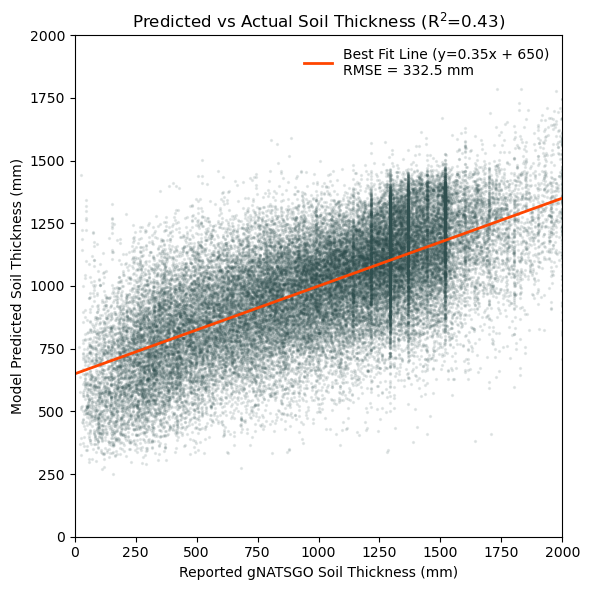

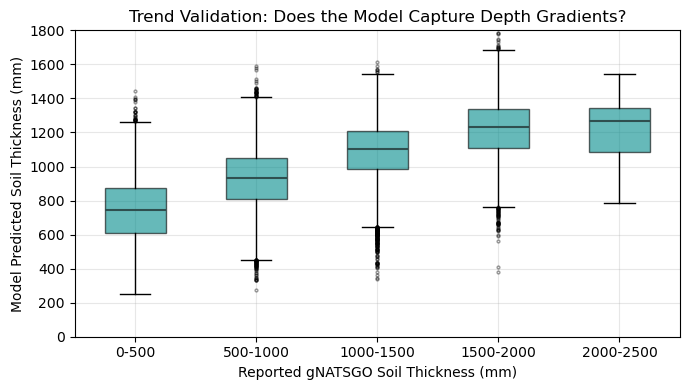

In [ ]:

# 1. LOAD DATA
df = pd.read_csv('C:\\Users\\mradwin\\Documents\\Utah Soil Water Balance\\soil_thickness_machine_learning\\Validation_Stats_70_30_Split_Statified_Sampling_SlopeAspectTPINdviLandcoverCroplandLithology.csv')

# --- UNIT CHECK ---
max_val = df['thickness'].max()
units = "mm" if max_val > 500 else "cm"
print(f"Detected Units: {units} (Max value: {max_val})")

# 2. AGGREGATE TO ZONAL MEANS
# We average all points falling inside the same polygon (mukey)
zonal = df.groupby('mukey').agg({
    'thickness': 'mean',       # Actual (should be constant per polygon)
    'classification': 'mean',  # Predicted (average of the random points)
    'mukey': 'count'           # Count of points per polygon
}).rename(columns={'mukey': 'count'})

# Filter: Only validate polygons where we had at least 3 test points
# This removes noise from tiny slivers
valid_zonal = zonal[zonal['count'] >= 3]
print(f"Validating on {len(valid_zonal)} unique Soil Map Units.")

# sample_size = min(20000, len(valid_zonal))
# valid_zonal = valid_zonal.sample(n=sample_size, random_state=42)

# 3. CALCULATE METRICS
y_true = valid_zonal['thickness']
y_pred = valid_zonal['classification']

r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"------------------------------------------------")
print(f"FINAL MODEL PERFORMANCE ({units})")
print(f"R2 Score: {r2:.3f}")
print(f"RMSE:     {rmse:.1f} {units}")
print(f"------------------------------------------------")

# --- PLOT 1: SCATTER PLOT ---
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.1, s=2, c='darkslategrey')

# Dynamic 1:1 line based on data range
limit = max(y_true.max(), y_pred.max())
# plt.plot([0, limit], [0, limit], 'r-', linewidth=2, label='1:1 Perfect Match')

# 2. FITTED REGRESSION LINE (Blue Trend)
# Calculate slope (m) and intercept (b) using the FULL dataset (not just the sample)
m, b = np.polyfit(y_true, y_pred, 1)

# Create the line coordinates
x_fit = np.array([0, limit])
y_fit = m * x_fit + b

plt.plot(x_fit, y_fit, 'orangered', linewidth=2, label=f'Best Fit Line (y={m:.2f}x + {b:.0f})\nRMSE = {rmse:.1f} {units}')

plt.xlabel(f'Reported gNATSGO Soil Thickness ({units})')
plt.ylabel(f'Model Predicted Soil Thickness ({units})')
plt.title(f'Predicted vs Actual Soil Thickness (R$^2$={r2:.2f})')
plt.legend(frameon=False)
# plt.grid(True, alpha=0.3)
plt.xlim(0, 2000)
plt.ylim(0, 2000)
plt.tight_layout()
# plt.savefig('C:\\Users\\mradwin\\Documents\\Utah Soil Water Balance\\soil_thickness_machine_learning\\Validation figures\\soil_thickness_random_forest_scatterplot_validation.jpg', dpi=600)
plt.show()

# --- PLOT 2: BINNED BOX PLOT (The Trend Proof) ---
# Create bins every 50 units (e.g., 50cm or 500mm depending on scale)
bin_step = 50 if units == 'cm' else 500
bins = np.arange(0, limit + bin_step, bin_step)
labels = [f"{int(i)}-{int(i+bin_step)}" for i in bins[:-1]]

valid_zonal['Actual_Bin'] = pd.cut(valid_zonal['thickness'], bins=bins, labels=labels)

# Prepare data for matplotlib boxplot
plot_data = []
clean_labels = []
for label in labels:
    subset = valid_zonal[valid_zonal['Actual_Bin'] == label]['classification']
    if len(subset) > 0: # Only plot bins that have data
        plot_data.append(subset.values)
        clean_labels.append(label)

plt.figure(figsize=(7, 4))
plt.boxplot(plot_data, labels=clean_labels, patch_artist=True,
            boxprops=dict(facecolor='darkcyan', color='black', alpha=0.6),
            medianprops=dict(color='darkslategrey', linewidth=1.5),
            flierprops=dict(color='darkslategrey', alpha=0.4, markersize=4, marker='.'))
plt.xlabel(f'Reported gNATSGO Soil Thickness ({units})')
plt.ylabel(f'Model Predicted Soil Thickness ({units})')
plt.title('Trend Validation: Does the Model Capture Depth Gradients?')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1800)
# plt.legend()
# plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig('C:\\Users\\mradwin\\Documents\\Utah Soil Water Balance\\soil_thickness_machine_learning\\Validation figures\\soil_thickness_random_forest_boxplot_validation.jpg', dpi=600)
plt.show()

Hydrologic Classification Accuracy: 60.9%


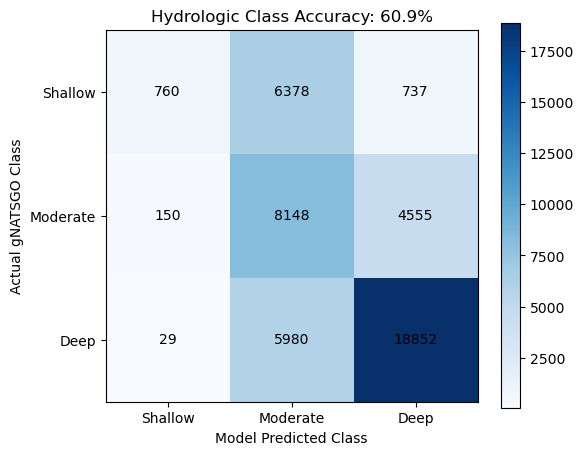

In [10]:
# 1. Define Classification Logic
def classify_soil(depth_mm):
    if depth_mm < 500: return 'Shallow'
    elif depth_mm < 1000: return 'Moderate'
    else: return 'Deep'

# Apply the classification
y_true = valid_zonal['thickness'].apply(classify_soil)
y_pred = valid_zonal['classification'].apply(classify_soil)
# df['Class_Actual'] = df['thickness'].apply(classify_soil)
# df['Class_Pred'] = df['classification'].apply(classify_soil)

# 2. Calculate Metrics
labels = ['Shallow', 'Moderate', 'Deep']
cm = confusion_matrix(y_true, y_pred, labels=labels)
acc = accuracy_score(y_true, y_pred)

print(f"Hydrologic Classification Accuracy: {acc:.1%}")

# 3. Plot Heatmap manually using Matplotlib
fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.matshow(cm, cmap='Blues') # Use 'Blues' colormap
fig.colorbar(cax)

# Add text annotations to each square
for (i, j), val in np.ndenumerate(cm):
    ax.text(j, i, f'{val}', ha='center', va='center', color='black')

# Fix axis labels
ax.set_xticklabels([''] + labels)
ax.set_yticklabels([''] + labels)
ax.xaxis.set_ticks_position('bottom') # Move X labels to bottom

plt.xlabel('Model Predicted Class')
plt.ylabel('Actual gNATSGO Class')
plt.title(f'Hydrologic Class Accuracy: {acc:.1%}')
plt.show()

### All the layers added to a map, as a way to inspect the predicted soil thickness to gNATSGO and other inputs

In [9]:
Map = geemap.Map(center=[39.5, -111.5], zoom=7)
# Map.addLayer(dem, vis_params={'min':0, 'max':4000, 'palette':get_palette('terrain')}, name='DEM')
# Map.addLayer(predicted_thickness_asset, vis_params={'bands':['classification'], 'min':0, 'max':2000, 'palette':get_palette('viridis')}, name='Predicted Soil Thickness')
# Map.addLayer(gNATSGO, vis_params={'bands':['tk0_999a'], 'min':0, 'max':2000, 'palette':get_palette('viridis')}, name='gNATSGO TK')
Map.addLayer(predictor_raster_asset, vis_params={'bands':['TPI'], 'min':-10, 'max':10, 'palette':get_palette('viridis')}, name='TPI')
Map.addLayer(predictor_raster_asset, vis_params={'bands':['elevation'], 'min':0, 'max':3000, 'palette':get_palette('viridis')}, name='elevation')
Map.addLayer(predictor_raster_asset, vis_params={'bands':['aspect'], 'min':0, 'max':360, 'palette':get_palette('viridis')}, name='aspect')
Map.addLayer(predictor_raster_asset, vis_params={'bands':['slope'], 'min':0, 'max':45, 'palette':get_palette('viridis')}, name='slope')
Map.addLayer(predictor_raster_asset, vis_params={'bands':['ndvi'], 'min':-0.2, 'max':0.5, 'palette':get_palette('viridis')}, name='ndvi')
Map.addLayer(predictor_raster_asset, vis_params={'bands':['landcover'], 'min':0, 'max':120, 'palette':get_palette('viridis')}, name='landcover')
Map.addLayer(predictor_raster_asset, vis_params={'bands':['cropland'], 'min':0, 'max':300, 'palette':get_palette('viridis')}, name='cropland')
Map.addLayer(predictor_raster_asset, vis_params={'bands':['lithology'], 'min':0, 'max':12, 'palette':get_palette('viridis')}, name='lithology')
Map.addLayer(predictor_raster_asset, vis_params={'bands':['tk0_999a'], 'min':0, 'max':2000, 'palette':get_palette('viridis')}, name='gNATSGO')
Map.addLayer(final_soil_thickness_prediction_raster, vis_params={'bands':['soil_thickness'], 'min':0, 'max':2000, 'palette':get_palette('viridis')}, name='soil thickness ML')
Map.addLayer(soil_thickness_prediction_impervious_accounting, vis_params={'bands':['soil_thickness'], 'min':0, 'max':2000, 'palette':get_palette('viridis')}, name='soil thickness imperv ML')
Map.addLayer(soil_thickness_prediction_impervious_accounting_1km_resampled, vis_params={'bands':['soil_thickness'], 'min':0, 'max':2000, 'palette':get_palette('viridis')}, name='soil thickness imperv ML 1km')

Map

Map(center=[39.5, -111.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…